In [1]:
import sys
import os

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

import torch
import pandas as pd
import numpy as np

from datetime import datetime

from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output

from src.nca.utils import L2, make_seed, load_image
from src.nca.model import NCADish


/home/wallace/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:

def adapt_env(model, cs, target):
    length = np.random.randint(64, 96)

    for n in range(length):
        cs = model(cs)

    target_channel = target.shape[1]
    batch_loss, total_loss = L2(cs[:, :target_channel, ...], target)
    return batch_loss, total_loss, cs


In [3]:
model = NCADish(
    width = 28,
    height = 28,
    channels = 8,
    device="cuda"
)

In [4]:
target = load_image("../test_data/lenna.png", size=28)
seed = make_seed(28,28)

board = model.seed(seed)
target = model.target(target)

In [5]:
def plot_loss(losses,
                        trend_window=101,    # odd preferred for some filters; must be > noise_window
                        noise_window=21,     # window to compute noise std
                        figsize=(12,6)):
    """
    losses: 1D array-like of loss values
    trend_window: window size (samples) used to compute slow trend (moving average)
    noise_window: window size used to compute rolling std of residuals (noise)
    """
    s = pd.Series(losses)
    # Slow trend via moving average (centered)
    trend = s.rolling(window=trend_window, center=True, min_periods=1).mean()
    # Residuals = high-frequency component (loss - trend)
    resid = s - trend
    # Rolling std of residuals = instantaneous noise amplitude
    noise_std = resid.rolling(window=noise_window, center=True, min_periods=1).std()

    # Also coefficient of variation of residuals relative to local trend magnitude (optional)
    # Use abs(trend) to avoid sign issues and add small eps to avoid division by zero
    eps = 1e-12
    noise_cv = noise_std / (trend.abs() + eps)

    # Plotting: 3 subplots
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 3, figsize=figsize)

    # 1) All losses + trend
    axes[0][0].plot(s.index, s.values, label='Loss', linewidth=1)
    axes[0][0].plot(trend.index, trend.values, label=f'Trend (window={trend_window})',
                 color='red', linewidth=2)
    axes[0][0].set_title('Loss & Trend')
    axes[0][0].set_xlabel('Step')
    axes[0][0].set_ylabel('Loss')
    axes[0][0].legend()

    # 2) Residuals (detrended signal)
    axes[0][1].plot(resid.index, resid.values, label='Residual (loss - trend)')
    axes[0][1].axhline(0, color='k', linewidth=0.5, linestyle='--')
    axes[0][1].set_title('Residuals (High-frequency)')
    axes[0][1].set_xlabel('Step')
    axes[0][1].set_ylabel('Residual')

    # 3) Rolling std of residuals (noise measure)
    axes[0][2].plot(noise_std.index, noise_std.values, label=f'Noise std (window={noise_window})')
    axes[0][2].plot(noise_cv.index, noise_cv.values, label='Noise CV (std/|trend|)', alpha=0.7)
    axes[0][2].set_title('Noise (rolling std) and CV')
    axes[0][2].set_xlabel('Step')
    axes[0][2].set_ylabel('Noise')
    axes[0][2].legend()

    # 4) Most recent 200 samples
    axes[1][0].plot(losses[-200:], label=f'Loss (window={200})')
    axes[1][0].set_title('Most recent loss [200 samples]')
    axes[1][0].set_xlabel('Step')
    axes[1][0].set_ylabel('Loos')
    axes[1][0].legend()

    # 4) Most recent 200 samples
    axes[1][1].plot([np.var(losses[n:n+20]) for n in range(len(losses))], label=f'Variance window=20')
    axes[1][1].set_title('Windowed Variance')
    axes[1][1].set_xlabel('Step')
    axes[1][1].set_ylabel('Loos')
    axes[1][1].legend()

    plt.tight_layout()
    plt.show()


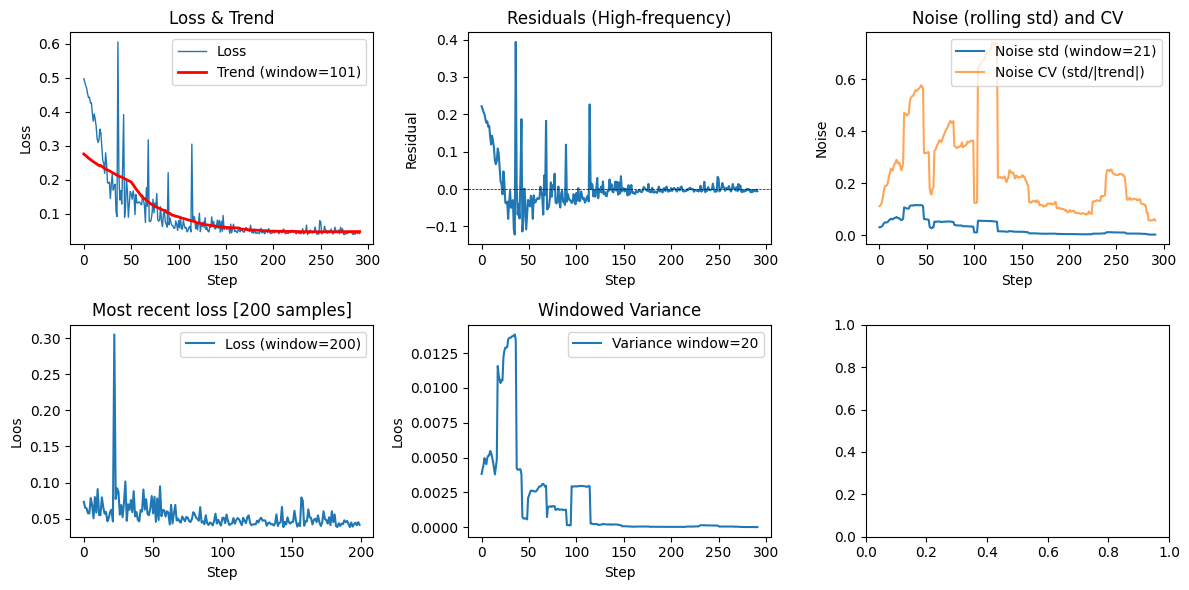

Epoch [292], Loss: 0.0415:  58%|█████▊    | 292/500 [11:35<08:15,  2.38s/it]


KeyboardInterrupt: 

In [6]:
testable_model, avg_loss = model.grow(
    env=adapt_env,
    epochs=500,
    learnign_rate=0.0002,
    pool_size=1024,
    loss_callback=plot_loss,
)

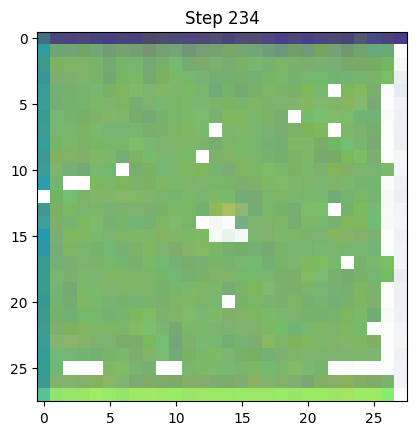

In [ ]:
frame = model.seed(seed)
testable_model = model.get_latest_model()
frames = []
for n in range(96*3):
    # Example: list of frames (NumPy arrays)
    frame = testable_model(frame)
    frame_np = frame.permute(0, 2, 3, 1).cpu().detach().numpy()[0]  # (H, W, C)
    frame_np = (frame_np[..., :4] * 255).astype(np.uint8)
    
    # Clear previous output and draw new frame
    clear_output(wait=True)
    plt.imshow(frame_np, cmap='plasma')
    plt.title(f"Step {n}")
    plt.show()
